# Problem D: Prediction of Traffic Flow based on Burgers’ Equation Model

Burgers' equation is a classical PDE model that captures the interplay between nonlinear convection and diffusion, making it well-suited for describing traffic flow dynamics. In this context, the convective term models the tendency for traffic to compress as vehicle density increases, while the diffusive term reflects the smoothing effect of individual driver reactions to surrounding traffic conditions.

The viscous Burgers' equation governing the evolution of vehicle velocity is:

$$
u_t + uu_x = \nu u_{xx}, \qquad x\in(-1,1),\ t\in(0,1] \tag{3}
$$

where:
- $u(x,t)$: vehicle velocity field (m/s),
- $\nu = 0.1/\pi$: kinematic viscosity coefficient (a higher value reflects more cautious, diffusive driver behavior),
- $x$: position along the road segment,
- $t$: time.

Homogeneous Dirichlet boundary conditions are imposed at both ends of the road:

$$
u(-1,\, t) = u(1,\, t) = 0, \qquad t \in (0, 1]
$$

Given an initial velocity profile $u(x, 0) = a(x)$, the full spatio-temporal velocity field $u(x,t)$ for $t > 0$ is uniquely determined by solving Eq. (3). In practice, however, running a high-fidelity finite difference solver for every new initial condition is computationally prohibitive. The goal of this task is therefore to learn a fast surrogate that approximates the solution operator $a(x) \mapsto u(x,t)$.

## Task: predicting the velocity filed $u(x,t)$ given the inital field $a(x)$ 

A dataset of initial conditions $a(x)$ sampled from a distribution $\mathcal{A}$ has been collected, along with the corresponding velocity fields $u(x,t)$ computed by a high-precision Finite Difference Method (FDM) solver. The dataset is **partially labeled**: only a small subset of initial conditions is paired with its FDM solution, while a much larger set of initial conditions has no corresponding solution available. This reflects a realistic scenario in which high-fidelity simulation data is scarce and expensive to obtain. The trained surrogate model should accurately predict $u(x,t)$ for any new initial condition $a(x)$ drawn from the same distribution $\mathcal{A}$, at negligible computational cost.

### Goals

- Select a suitable deep learning method for this task and justify your choice. 
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The error is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\displaystyle\sum_i\left|u^{(j)}_{\text{pred}}(x_i,t_i)-u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}{\displaystyle\sum_i\left|u^{(j)}_{\text{true}}(x_i,t_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatio-temporal grid point.

- For the **first test instance**, use `matplotlib` to produce four separate figures:
  1. The initial condition $a(x) = u(x, 0)$
  2. The predicted velocity field $u_{\text{pred}}(x,t)$
  3. The ground truth velocity field $u_{\text{true}}(x,t)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

All data are provided in `ProblemD_dataset.h5`:

| Key | Shape | Description |
|---|---|---|
| `a_train_labeled` | (200, 256) | $N=200$ **labeled** initial fields, sampled at 256 spatial sensors |
| `u_train_labeled` | (200, 200, 256) | Corresponding FDM-computed velocity fields on a $200\times256$ spatio-temporal grid |
| `a_train_unlabeled` | (1800, 256) | $N=1800$ **unlabeled** initial fields (no paired solution available) |
| `a_test` | (200, 256) | Test initial conditions (**do not use for training**) |
| `u_test` | (200, 200, 256) | Ground truth velocity fields for test instances (**do not use for training**) |
| `x_mesh` | (256, 1) | Spatial coordinates of the 256 grid points |
| `t_mesh` | (200, 1) | Temporal coordinates of the 200 time steps |

> 📥 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

In [ ]:
#### DATA, HYPERPARAMETERS, LIBRARIES AND DEFINITIONS ####

import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import grad, Variable
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

np.random.seed(67)
torch.manual_seed(67)

DEVICE        = torch.device('cuda')
DATA_TYPE     = torch.float32
LEARNING_RATE = 0.001
WEIGHT_DECAY  = 0.0001
EPOCHS        = 500
WEIGHT_PDE    = 1.0
WEIGHT_DATA   = 1.0
NU            = 0.1 / np.pi

DATA_PATH = 'ProblemD_dataset.h5'

with h5py.File(DATA_PATH, 'r') as file:
    t_mesh              = torch.tensor(np.array(file['t_mesh']), dtype=DATA_TYPE)
    x_mesh              = torch.tensor(np.array(file['x_mesh']), dtype=DATA_TYPE)
    a_test              = torch.tensor(np.array(file['a_test']), dtype=DATA_TYPE)
    u_test              = torch.tensor(np.array(file['u_test']), dtype=DATA_TYPE)
    a_train_labeled     = torch.tensor(np.array(file['a_train_labeled']), dtype=DATA_TYPE)
    u_train_labeled     = torch.tensor(np.array(file['u_train_labeled']), dtype=DATA_TYPE)
    a_train_unlabeled   = torch.tensor(np.array(file['a_train_unlabeled']), dtype=DATA_TYPE)

N_X, N_T = x_mesh.shape[0], t_mesh.shape[0]

X, T = np.meshgrid(x_mesh, t_mesh)
mesh = np.vstack([X.ravel(), T.ravel()])
grid = torch.tensor(mesh.T, dtype = DATA_TYPE, device=DEVICE)   # (N_T*N_X, 2), rows: t-major, x-minor

LAYERS_TRUNK  = [grid.shape[-1], 128, 128, 128, 128]
LAYERS_BRANCH = [a_train_labeled.shape[-1], 128, 128, 128, 128]

In [11]:
#### CLASSES DEFINITION ####

class DeepONet(nn.Module):

    def __init__(self, layers_trunk, layers_branch):
        super(DeepONet, self).__init__()
        self.activation_trunk  = nn.Tanh()   
        self.activation_branch = nn.Tanh()   
        self.branch_net(layers_branch)
        self.trunk_net(layers_trunk)
        self.bias = nn.Parameter(torch.tensor(0.0, dtype=DATA_TYPE))

    def branch_net(self, layers_branch):
        net, hidden_in = [], layers_branch[0]
        for hidden in layers_branch[1:-1]:
            net += [nn.Linear(hidden_in, hidden, dtype=DATA_TYPE), self.activation_branch]
            hidden_in = hidden
        net.append(nn.Linear(hidden_in, layers_branch[-1], dtype=DATA_TYPE))
        self.branch = nn.Sequential(*net)

    def trunk_net(self, layers_trunk):
        net, hidden_in = [], layers_trunk[0]
        for hidden in layers_trunk[1:-1]:
            net += [nn.Linear(hidden_in, hidden, dtype=DATA_TYPE), self.activation_trunk]
            hidden_in = hidden
        net.append(nn.Linear(hidden_in, layers_trunk[-1], dtype=DATA_TYPE))
        self.trunk = nn.Sequential(*net)

    def forward(self, x, a):
        """
        x : (M, 2) grid of (x, t) query points, shared by the whole batch
        a : (B, N_sensor) initial-condition sensor values      
        """
        branch_out = self.branch(a)
        trunk_out = self.trunk(x)
        dot_product = torch.einsum("bp,mp->bm", branch_out, trunk_out)
        output = dot_product + self.bias

        # Enforce boundary condition
        bc_mask = 1.0 - x[:, 0] ** 2
        output = output * bc_mask

        return output

class LossClass(object):

    def __init__(self, u_model, lambda_r, lambda_d, sensor_grid):
        """
        Args:
            u_model     : DeepONet
            lambda_r    : weight for PDE residual loss
            lambda_d    : weight for supervised data loss (0 = fully physics-informed)
            sensor_grid : (N_T*N_X, 2) fixed (x, t) grid used to evaluate the PDE residual
        """
        self.u_model     = u_model
        self.lambda_r    = lambda_r
        self.lambda_d    = lambda_d
        self.sensor_grid = sensor_grid
        self.nu = NU
        self.n_x, self.n_t = N_X, N_T
        self.dx = (x_mesh[1] - x_mesh[0]).item()
        self.dt = (t_mesh[1] - t_mesh[0]).item()

    def loss_pde(self, a_batch):
        """
            u_t + u u_x - nu u_xx = 0
        """
        n_batch = a_batch.shape[0]
        x = self.sensor_grid.to(a_batch)
        u = self.u_model(x, a_batch)
        u = u.reshape(n_batch, self.n_t, self.n_x)   # (B, N_t, N_x): rows = t, cols = x

        u_c  = u[:, 1:-1, 1:-1]
        u_t  = (u[:, 2:, 1:-1] - u[:, :-2, 1:-1]) / (2 * self.dt)
        u_x  = (u[:, 1:-1, 2:] - u[:, 1:-1, :-2]) / (2 * self.dx)
        u_xx = (u[:, 1:-1, 2:] - 2 * u_c + u[:, 1:-1, :-2]) / (self.dx ** 2)

        residual = u_t + u_c * u_x - self.nu * u_xx
        loss = torch.norm(residual.reshape(n_batch, -1), 2, dim=1)
        return torch.mean(loss)

    def loss_data(self, a_batch, u_batch, x):
        u_pred = self.u_model(x, a_batch)
        loss = torch.norm(u_batch - u_pred, 2, dim=1)
        return torch.mean(loss)

    def loss_total(self, a_batch, u_batch, x):
        """
        Total loss = lambda_r * L_pde  [+ lambda_d * L_data]
        """
        loss = self.lambda_r * self.loss_pde(a_batch)
        if self.lambda_d > 0 and u_batch is not None and x is not None:
            loss = loss + self.lambda_d * self.loss_data(a_batch, u_batch, x)
        return loss

    def get_error(self, a, u, x):
        """L2 relative error — uses labeled test pairs for evaluation only."""
        u_pred = self.u_model(x, a)
        error  = torch.norm(u - u_pred, 2, dim=1) / torch.norm(u, 2, dim=1)
        return torch.mean(error)

class MyDataset(Dataset):
    def __init__(self, a: torch.Tensor, u: torch.Tensor = None):
        self.a = a
        self.u = u 

    def __getitem__(self, index):
        if self.u is not None:
            return self.a[index], self.u[index]
        return (self.a[index],)

    def __len__(self):
        return self.a.shape[0]

In [12]:
#### STAGE MODEL ####

BATCH_SIZE_LABELED   = 50
BATCH_SIZE_UNLABELED = 450

uModel               = DeepONet(LAYERS_TRUNK, LAYERS_BRANCH).to(DEVICE)
dataLoader           = DataLoader(MyDataset(a_train_labeled, u_train_labeled), batch_size=BATCH_SIZE_LABELED, shuffle=True)
dataLoader_unlabeled = DataLoader(MyDataset(a_train_unlabeled), batch_size=BATCH_SIZE_UNLABELED, shuffle=True)
lossClass            = LossClass(uModel, WEIGHT_PDE, WEIGHT_DATA, grid)

OPTIMIZER = torch.optim.Adam(uModel.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
SCHEDULER = torch.optim.lr_scheduler.StepLR(OPTIMIZER, step_size=int(EPOCHS/6), gamma=0.5)

In [13]:
#### TRAINING LOOP ####

loss_list, error_list = [], []
for epoch in range(EPOCHS):
    uModel.train()
    epoch_loss = 0.0

    for batch, batch_unlabeled in zip(dataLoader, dataLoader_unlabeled):
        a_batch = batch[0].to(DEVICE)
        u_batch = batch[1].reshape(batch[1].shape[0], -1).to(DEVICE)
        a_unlabeled_batch = batch_unlabeled[0].to(DEVICE)

        # Labeled batch: data + PDE residual. Unlabeled batch: PDE residual only
        loss_train = lossClass.loss_total(a_batch, u_batch, grid) + lossClass.lambda_r * lossClass.loss_pde(a_unlabeled_batch)

        OPTIMIZER.zero_grad()
        loss_train.backward()
        OPTIMIZER.step()
        epoch_loss += loss_train.item()

    SCHEDULER.step()

    uModel.eval()
    with torch.no_grad():
        error = lossClass.get_error(
            a_test.to(DEVICE), u_test.reshape(u_test.shape[0], -1).to(DEVICE), grid.to(DEVICE)
        )
        error_list.append(error.item())

    epoch_loss /= len(dataLoader)
    loss_list.append(epoch_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:4d} | PDE loss: {epoch_loss:.4e} 'f'| Test L2 rel. error: {error_list[-1]:.4e}')

Epoch    5 | PDE loss: 2.4782e+01 | Test L2 rel. error: 7.1418e-01
Epoch   10 | PDE loss: 2.1839e+01 | Test L2 rel. error: 6.7505e-01
Epoch   15 | PDE loss: 2.0984e+01 | Test L2 rel. error: 6.5599e-01
Epoch   20 | PDE loss: 2.0143e+01 | Test L2 rel. error: 6.4172e-01
Epoch   25 | PDE loss: 1.9633e+01 | Test L2 rel. error: 6.1502e-01
Epoch   30 | PDE loss: 1.9324e+01 | Test L2 rel. error: 5.8864e-01
Epoch   35 | PDE loss: 1.9108e+01 | Test L2 rel. error: 5.9759e-01
Epoch   40 | PDE loss: 1.8986e+01 | Test L2 rel. error: 5.8585e-01
Epoch   45 | PDE loss: 1.8870e+01 | Test L2 rel. error: 5.7628e-01
Epoch   50 | PDE loss: 1.8733e+01 | Test L2 rel. error: 5.9633e-01
Epoch   55 | PDE loss: 1.8635e+01 | Test L2 rel. error: 5.9767e-01
Epoch   60 | PDE loss: 1.8525e+01 | Test L2 rel. error: 5.8084e-01
Epoch   65 | PDE loss: 1.8283e+01 | Test L2 rel. error: 5.7289e-01
Epoch   70 | PDE loss: 1.7912e+01 | Test L2 rel. error: 5.6542e-01
Epoch   75 | PDE loss: 1.7315e+01 | Test L2 rel. error: 5.5246

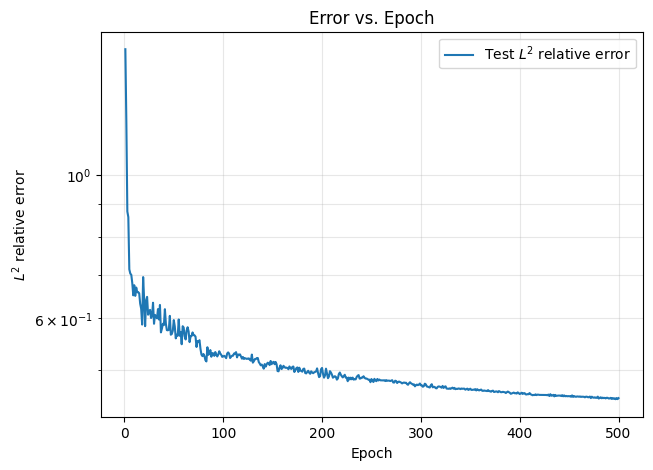

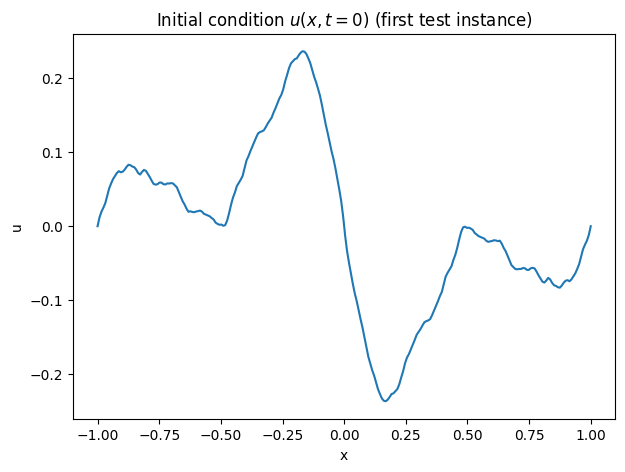

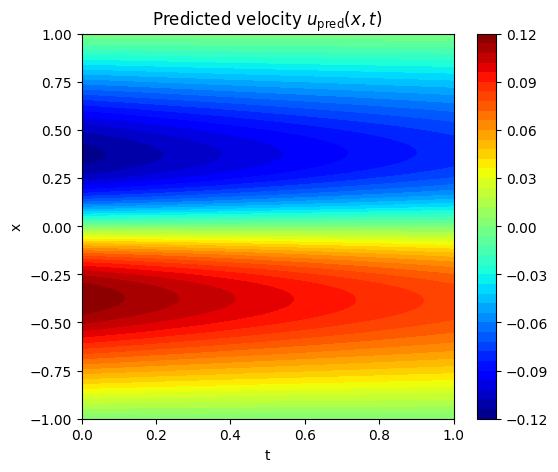

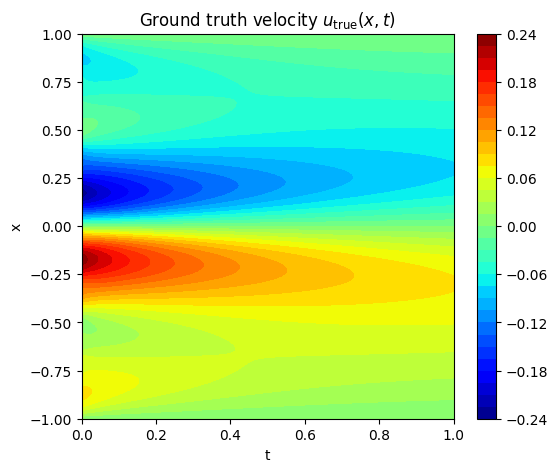

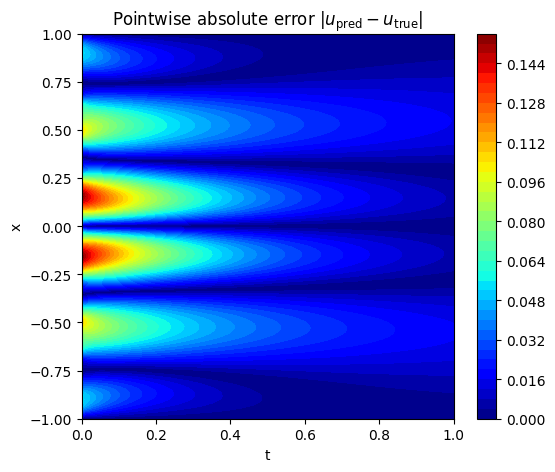

In [ ]:
#### PLOTTING ####

uModel.eval()
with torch.no_grad():
    u_pred0 = uModel(grid, a_test[:1].to(DEVICE)).cpu()[0].reshape(N_T, N_X)
a0 = a_test.cpu()[0]
u_true0 = u_test.cpu()[0]
abs_err0 = (u_pred0 - u_true0).abs()

plt.figure(figsize=(7, 5))
plt.semilogy(range(1, EPOCHS + 1), error_list, label='Test $L^2$ relative error')
plt.xlabel('Epoch')
plt.ylabel('$L^2$ relative error')
plt.title('Error vs. Epoch')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

# Initial condition a(x) = u(x, t=0)
plt.figure(figsize=(7, 5))
plt.plot(x_mesh.numpy(), a0.numpy())
plt.title('Initial condition $u(x, t=0)$ (first test instance)')
plt.xlabel('x')
plt.ylabel('u')
plt.show()

# Predicted velocity field
plt.figure(figsize=(6, 5))
cs = plt.contourf(T, X, u_pred0, levels=40, cmap='jet')
plt.colorbar(cs)
plt.title('Predicted velocity $u_{\\mathrm{pred}}(x,t)$')
plt.xlabel('t')
plt.ylabel('x')
plt.show()

# Ground truth velocity field
plt.figure(figsize=(6, 5))
cs = plt.contourf(T, X, u_true0, levels=40, cmap='jet')
plt.colorbar(cs)
plt.title('Ground truth velocity $u_{\\mathrm{true}}(x,t)$')
plt.xlabel('t')
plt.ylabel('x')
plt.show()

# Pointwise absolute error
plt.figure(figsize=(6, 5))
cs = plt.contourf(T, X, abs_err0, levels=40, cmap='jet')
plt.colorbar(cs)
plt.title('Pointwise absolute error $|u_{\\mathrm{pred}} - u_{\\mathrm{true}}|$')
plt.xlabel('t')
plt.ylabel('x')
plt.show()